In [2]:
import base64
from IPython.display import display, Markdown

# -------- Encoding Images in Base64 --------
def encode_image(file_path):
    with open(file_path, "rb") as img:
        return base64.b64encode(img.read()).decode()

encoded_flowchart = encode_image("flowChartML.png")
encoded_process = encode_image("ProcessML.png")

# -------- Creating Markdown Content --------
markdown_content = f"""
<h1 style="text-align:center; font-size:62px; font-weight:bold;">
Titanic Dataset Project
</h1>

<h2 style="font-size:42px; font-weight:bold;">
Objective
</h2>
To make a machine learning model that predicts who survived the Titanic accident and who could not survive.

---
<h2 style="font-size:42px; font-weight:bold;">
Work Flow Chart
</h2>

![Flowchart](data:image/png;base64,{encoded_flowchart})

*Image Source: Class Notes by Dr Massi Izzo*

---
<h3 style="font-size:42px; font-weight:bold;">
Process
</h3>

![Process](data:image/png;base64,{encoded_process})

*Image Source: Class Notes by Dr Massi Izzo*

---
<h4 style="font-size:42px; font-weight:bold;">
Description of the Dataset
</h4>

### Train Dataset Features:
PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked.

### Test Dataset Features:
PassengerId, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked.

- *SibSp* represents Number of siblings/spouses aboard.  
- *Parch* represents Number of parents/children aboard.  

### Key Difference:
* The train.csv dataset contains the targeted binary variable:
Survived ( where 0 = Could not survive, 1 = Survived).

* The test.csv dataset does not include the survived column.
"""

# -------- Displaying in Jupyter --------
display(Markdown(markdown_content))

# -------- Saving to Markdown File --------
with open("output.md", "w") as f:
    f.write(markdown_content)





FileNotFoundError: [Errno 2] No such file or directory: 'flowChartML.png'

In [3]:
# importing common Python Libraries
import sys
import numpy as ny
import pandas as ps
import os
import matplotlib.pyplot as plot
import seaborn as sea


In [4]:
# Reading the Training and Test Data.
from sklearn.model_selection import train_test_split
url_train = 'https://raw.githubusercontent.com/nabanitamahata/Titanic/refs/heads/main/train.csv'
TrainingData= ps.read_csv(url_train)
url_test = 'https://raw.githubusercontent.com/nabanitamahata/Titanic/refs/heads/main/test.csv'
TestData = ps.read_csv(url_test)
print(f"\nTrainingData size: ", TrainingData.shape)
print(f"TestData size: ", TestData.shape)


TrainingData size:  (891, 12)
TestData size:  (418, 11)


In [5]:
print(f"All the features in Training Set", TrainingData.info())
print(f"All the features in Test Set", TestData.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
All the features in Training Set None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId 

### Train dataset has extra 'Survived' feature which is not present for Test dataset. Others all the features are same in Training and Test Data set.

In [6]:
# Now we are splitting the Training data set into two parts, 80% data for the Training dataset (TrainData)  and 20% data for Validation dataset (ValidationData)
TrainData, ValidationData = train_test_split(TrainingData, test_size=0.2, random_state=42)
print(f"\nTrainData size: ", TrainData.shape)
print(f"ValidationData size: ", ValidationData.shape)


TrainData size:  (712, 12)
ValidationData size:  (179, 12)


In [7]:
#Showing 5 samples of TrainData)
TrainData.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
647,648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.50,A26,C
405,406,0,2,"Gale, Mr. Shadrach",male,34.0,1,0,28664,21.00,NaN,S
407,408,1,2,"Richards, Master. William Rowe",male,3.0,1,1,29106,18.75,NaN,S
355,356,0,3,"Vanden Steen, Mr. Leo Peter",male,28.0,0,0,345783,9.50,NaN,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,120.00,B96 B98,S


Total number of Passengers: 712
Total number of Passengers survived:  268

Total number of Male: 467
Total number of Female:  245

Total number of Female Survived 181
Female Survival Rate in % : 73.87755102040816

 Total number of Male Survived 87
Male Survival Rate in % : 18.629550321199144


TypeError: 'str' object is not callable

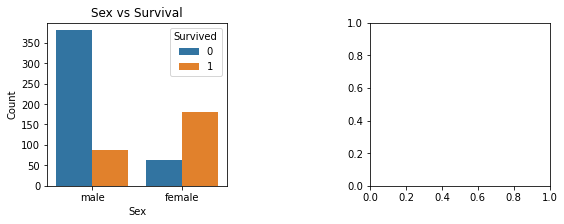

In [8]:
#....................Ploting two graphs in a single row.......................................
graph, column = plot.subplots(1, 2, figsize=(9,3))
plot.subplots_adjust(wspace=0.8)
#............................ Count plot for number of Male and Female Passengers ............................................
sea.countplot(
    x='Sex',
    hue='Survived',
    data=TrainData,
    ax= column[0]
)

column[0].set_title("Sex vs Survival")
column[0].set_xlabel("Sex")
column[0].set_ylabel("Count")

#.............................Findout Total number of survived passengers..............................................................
#Total Number of Passenger
TotalPassenger= len(TrainData['Sex'])
print("Total number of Passengers:", TotalPassenger)
#Total number of passengers survived 
TotalSurvived= (TrainData['Survived'] == 1). sum()
print("Total number of Passengers survived: ", TotalSurvived)


#.............................................Findout Percentage of Male survived and Female survived...............................
#Total Number of male 
TotalMale=(TrainData['Sex'] == 'male').sum()
print("\nTotal number of Male:", TotalMale)
#Total Number of female 
TotalFemale=(TrainData['Sex'] == 'female').sum()
print("Total number of Female: ", TotalFemale)
#Total Number of survived female 
TotalFemaleSurvived=(
    (TrainData['Survived'] == 1) &
    (TrainData['Sex'] == 'female')
).sum()
print("\nTotal number of Female Survived", TotalFemaleSurvived)
print("Female Survival Rate in % :", (TotalFemaleSurvived/TotalFemale)*100)
#Total Number of survived male 
TotalMaleSurvived=(
    (TrainData['Survived'] == 1) &
    (TrainData['Sex'] == 'male')
).sum()
print("\n Total number of Male Survived", TotalMaleSurvived)
print("Male Survival Rate in % :", (TotalMaleSurvived/TotalMale)*100)


# ............................................Bar plot for the percentage of Male and Female passengers survived................................
sea.barplot(
    x='Sex',
    y='Survived',
    data=TrainData,
    estimator='mean',
    errorbar=None,
    ax=column[1]
)

column[1].set_title("Survival Rate by Sex")
column[1].set_ylabel("Survival Rate")




plot.show()


#...............................Here we can verify the quantitative calculations with the diagram....................................


### We can come to the conclusion from the graphs of Sex and survied that more number of Female passengers were survived and The survival rate of Female is higher than man. There was total less number of Female passengers than Male passengers.


Total passengers in Class1: 163
Total passengers in Class2: 151
Total passengers in Class3: 398

Total survived passenger in Class1: 99
Survived passengers from all passengers among all Passengers in Class1 in %: 60.73619631901841

Total survived passenger in Class2: 73
Survived passengers from all passengers among all Passengers in Class2 in %: 48.34437086092716

Total survived passenger in Class3: 96
Survived passengers from all passengers among all Passengers in Class3 in %: 24.120603015075375


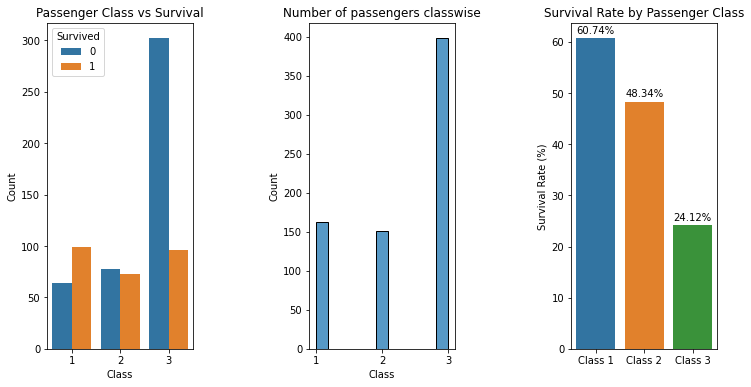

In [9]:
# .................................Ploting three graphs in a single row.............................................
graph, column = plot.subplots(1, 3, figsize=(12,6))
plot.subplots_adjust(wspace=0.8)
# .........................Survival according to class.........................................................................
sea.countplot(
    x='Pclass',
    hue='Survived',
    data=TrainData,
    ax =column[0]
)

column[0].set_title("Passenger Class vs Survival")
column[0].set_xlabel("Class")
column[0].set_ylabel("Count")



#........................................Number of  Passengers Classwise...........................

sea.histplot(
    x='Pclass',
    data=TrainData,
    ax=column[1]
)

column[1].set_title("Number of passengers classwise")
column[1].set_xlabel("Class")
column[1].set_ylabel("Count")

#............................................... Passengers survived according to class..............................

#Total Passengers in Class1
TotalPassengersClass1=(TrainData['Pclass']==1).sum()
print("\nTotal passengers in Class1:", TotalPassengersClass1)
TotalPassengersClass2=(TrainData['Pclass']==2).sum()
print("Total passengers in Class2:", TotalPassengersClass2)
TotalPassengersClass3=(TrainData['Pclass']==3).sum()
print("Total passengers in Class3:", TotalPassengersClass3)
#Total number of passenger in Class1
TotalSurvivedClass1=(
    (TrainData['Survived'] == 1) &
    (TrainData['Pclass'] == 1)
).sum()
print("\nTotal survived passenger in Class1:", TotalSurvivedClass1)
print("Survived passengers from all passengers among all Passengers in Class1 in %:", (TotalSurvivedClass1/TotalPassengersClass1)*100)
#Total number of passenger in Class2
TotalSurvivedClass2=(
    (TrainData['Survived'] == 1) &
    (TrainData['Pclass'] == 2)
).sum()
print("\nTotal survived passenger in Class2:", TotalSurvivedClass2)
print("Survived passengers from all passengers among all Passengers in Class2 in %:", (TotalSurvivedClass2/TotalPassengersClass2)*100)

#Total number of passenger in Class3
TotalSurvivedClass3=(
    (TrainData['Survived'] == 1) &
    (TrainData['Pclass'] == 3)
).sum()
print("\nTotal survived passenger in Class3:", TotalSurvivedClass3)
print("Survived passengers from all passengers among all Passengers in Class3 in %:", (TotalSurvivedClass3/TotalPassengersClass3)*100)




survival_rates = []

labels = ['Class 1', 'Class 2', 'Class 3']

for clas in [1, 2, 3]:
    total = (TrainData['Pclass'] == clas).sum()
    survived = ((TrainData['Pclass'] == clas) & (TrainData['Survived'] == 1)).sum()
    survival_rates.append((survived / total) * 100)

survival_rates
# Bar chart for Survival rate according to Class
sea.barplot(
    x=['Class 1', 'Class 2', 'Class 3'],
    y=survival_rates,
    ax=column[2]
)
column[2].set_ylabel('Survival Rate (%)')
column[2].set_title('Survival Rate by Passenger Class')

for index, value in enumerate(survival_rates):
    column[2].text(index, value + 1, f"{value:.2f}%", ha='center')


plot.show()
# We can verify the calculations from the graphs


### So, Survival rate Class 1 > Survival rate Class 2 > Survival rate Class 3

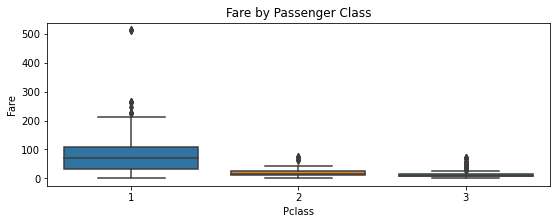

In [10]:
# ...........................Relation between Class and Fare.................................................
plot.figure(figsize=(9,3)) 
sea.boxplot(
    x='Pclass',
    y='Fare',
    data=TrainData
)

plot.title("Fare by Passenger Class")

plot.show()

### Fare of Class 1 > Fare of Class 2 > Fare of Class 3
### We know Sruvival rate of Class 1 > Sruvival rate of Class 2 > Sruvival rate of Class 3
### So, From the previous two chart, we can say that survival rate is higher for those who paid higher.

In [11]:
# .......................Relation between Embarked and Survived
plot.figure(figsize=(10,3))
sea.barplot(
    x='Embarked',
    y='Survived',
    data=TrainData,
    estimator='mean',
    errorbar=None
)

plot.title("Survival Rate by Embarked")
plot.ylabel("Survival Rate")
plot.show()

TypeError: 'str' object is not callable

<Figure size 720x216 with 0 Axes>

In [12]:
# Embarked C has highest servival rate means the Pssengers who boarded at C there suvival rate is highest.
# Embarked C survival rate > Embarked Q survival rate> Embarked S survival rate

In [13]:
# .....................................Finding out the relationship among Deck and survival.......................
# Creating a Column Deck from the First latter of Cabin
TrainData['Deck'] = TrainData['Cabin'].str[0]

sea.barplot(
    x='Deck',
    y='Survived',
    data=TrainData,
    estimator='mean',
    errorbar=None
)

plot.title("Survival by Deck")
plot.ylabel("Survival Rate")
plot.show()




<ipython-input-13-d446f4d30716>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TrainData['Deck'] = TrainData['Cabin'].str[0]


TypeError: 'str' object is not callable

### Deck E has highest survival rate

<ipython-input-14-2096fa5ff698>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TrainData["Title"] = (


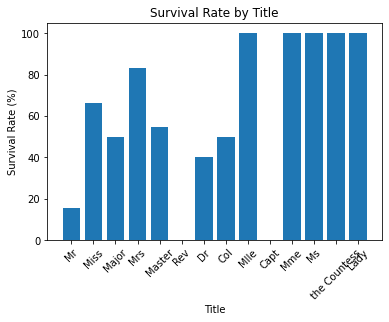

In [14]:
# ...................Extracting  Title from the Name Column..................................
TrainData["Title"] = (
    TrainData["Name"]
    .str.split(",", expand=True)[1]
    .str.split(".", expand=True)[0]
    .str.strip()
)

# ......................................................Getting unique titles....................................
titles = TrainData["Title"].unique()

# .............................Calculating survival percentage manually.................................................
Title_survival_pct = []

for t in titles:
    total = (TrainData["Title"] == t).sum()
    survived = ((TrainData["Title"] == t) & (TrainData["Survived"] == 1)).sum()
    pct = (survived / total) * 100
    Title_survival_pct.append(pct)

# .............................Ploting the graph for Survival rate by Title............................................
plot.bar(titles, Title_survival_pct)

plot.title("Survival Rate by Title")
plot.ylabel("Survival Rate (%)")
plot.xlabel("Title")
plot.xticks(rotation=45)
plot.show()




### No one could survive from Capt and Rev title



Outliers in Age:
[65.  70.5 70.  80.  74.  64.  70. ]

Outliers in SibSp:
[4 4 3 3 4 3 4 3 4 8 4 3 4 3 4 5 3 4 8 8 4 4 5 3 3 4 5 8 4 8 4 4 3 8 3 5 3
 3 8 4 5]

Outliers in Parch:
[2 1 1 1 2 2 2 2 2 1 1 1 1 1 1 2 2 2 2 2 1 2 1 1 1 1 1 2 1 1 2 2 2 1 1 2 1
 1 2 1 1 1 2 1 1 1 6 1 1 1 1 1 2 1 4 1 2 1 2 2 4 2 1 1 1 2 2 1 2 2 2 1 2 2
 1 1 1 2 2 1 1 1 1 1 2 2 1 2 3 1 1 1 2 1 1 1 2 1 2 1 5 1 1 1 2 1 3 1 1 1 1
 2 1 1 2 2 2 1 5 2 2 2 1 2 1 1 1 4 2 1 1 1 2 2 3 1 2 2 2 1 1 2 2 1 2 2 1 2
 2 1 2 1 2 1 2 1 2 1 1 5 1 1 1 1 1 2 1 1 2 2 1]

Outliers in Fare:
[247.5208  90.     227.525  120.     211.5     90.     151.55   262.375
  80.     227.525  133.65    77.9583 151.55   106.425   81.8583 153.4625
 110.8833 133.65    89.1042  80.      79.2     66.6     83.1583 211.3375
 106.425   65.      86.5     79.2    113.275   69.55   211.3375 263.
  73.5    164.8667  79.65    71.      69.3    153.4625 108.9     83.1583
 146.5208 263.      77.2875  69.55   227.525   90.     164.8667 512.3292
  69.55   512.3292  

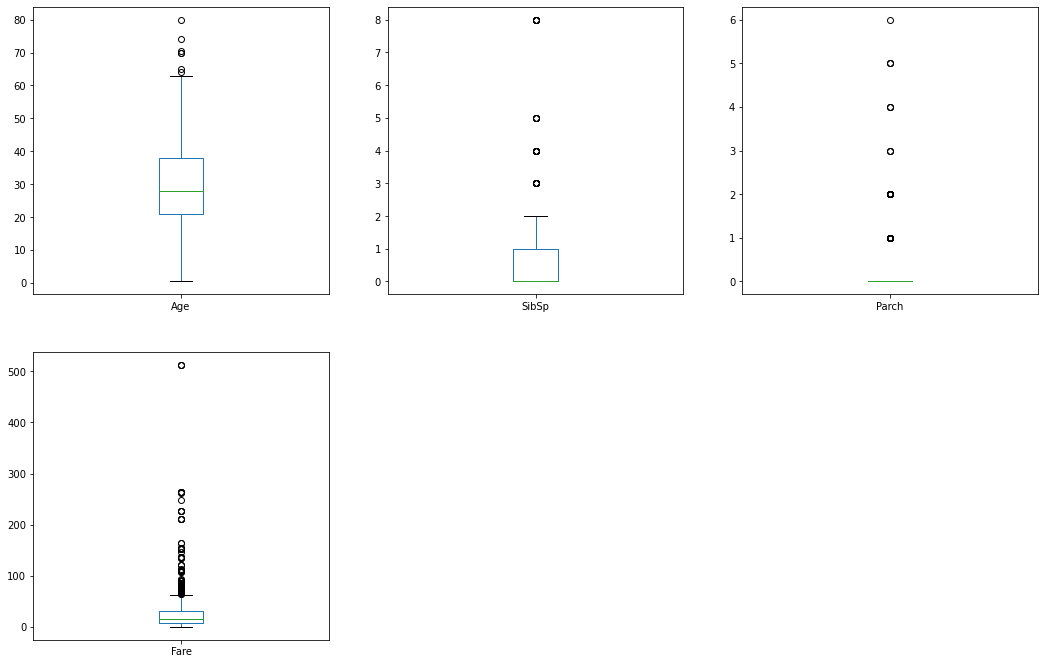

In [15]:
# Outlier detection

#Showing the outluers in Neumedical Features
p = TrainData[
    ['Age', 'SibSp', 'Parch', 
     'Fare']
].plot.box(subplots=True, layout=(3, 3), figsize=(18,18))

# Numerical columns
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']

for col in num_cols:
    Q1 = TrainData[col].quantile(0.25)
    Q3 = TrainData[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = TrainData[(TrainData[col] < lower) | (TrainData[col] > upper)][col]
    print(f"\nOutliers in {col}:")
    print(outliers.values)

### According to me, passengers having more than 62 years of age is normal. Outliers for sibSp, Parch and Fare are also normal but Age 0 and Fare 0 is not possible.

In [16]:
# Finding Corelation among neumerical features
Corelation_matrix = TrainData.corr(numeric_only=True)
Corelation_matrix["Survived"].sort_values(ascending=False)

TypeError: corr() got an unexpected keyword argument 'numeric_only'

In [17]:
### So, Here Fare has more corelation with survival than other neumerical features.

In [18]:

Train_dataset_pred = TrainData.drop(["PassengerId"], axis=1)

# check for multicolinearity with seaborn heatmap
# compute the correlation matrix
corr = round(Train_dataset_pred.corr(numeric_only=True), 3)

# set up the matplotlib figure
fig, ax = plot.subplots(figsize=(15, 12))

# generate a custom diverging colormap
cmap = sea.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
ax = sea.heatmap(
    corr,   # data
    cmap=cmap,  # colour map
    vmax=1,  # max value for colourmap
    vmin=-1,    # min value for colourmap
    center=0,   # central value for colourmap
    square=True,    # set the two axes to be equal - square map
    linewidths=1,   # width of the lines that separate each cell
    cbar_kws={"shrink": .75},
    annot=True  # print value in each cell of the heatmap
)

plot.show()

TypeError: corr() got an unexpected keyword argument 'numeric_only'

### So, Survival is highly corealated to Fare which saw before.
### Suvival is also corelated to Parch and SibSp. So, those who were with family they helped each-other to survive.
### Now we will check the family size.

In [19]:
#..........................................................Family Size..........................................
TrainData['Family_Size'] = TrainData['SibSp'] + TrainData['Parch'] + 1

TrainData[['SibSp', 'Parch', 'Family_Size']].head()



<ipython-input-19-c01693bfc843>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TrainData['Family_Size'] = TrainData['SibSp'] + TrainData['Parch'] + 1


,SibSp,Parch,Family_Size
331,0,0,1
733,0,0,1
382,0,0,1
704,1,0,2
813,4,2,7


In [20]:
# ...........................Boxplot Survival rate according to family size.................................
sea.barplot(
    x='Family_Size',
    y= 'Survived',  # 0 = died, 1 = survived
    data=TrainData,
    estimator='mean'
)
plot.title("Survival Rate by Family Size")
plot.ylabel("Survival Rate (0-1)")
plot.show()

TypeError: 'str' object is not callable

### Till Family Size 4 the survival rate is gradually increasing. So, their family members helped each other to survive.

## Conclusion from from data exploration
### 1. I will  creat a binary 'Family' feature (TrainData["Family"]=TrainData["SibSp"] + TrainData["Parch"] + 1,    if Family size is more than 1 then the value will be 1. Otherwise it will be 0 and remove  
### 2. I have decided to replace 'Fare == 0' with miningful values
### 3. I have to replace 'missing values' from 'Age' and 'Fare'
### 4. I have decided to Add Deck Categorical Feature , replace the missing values and delete 'cabin' feature 
### 5. I will drop PassengerId
### 6. I will replace the Pclass and Deck 'NaN' value with suitable value
### 7. I want to create another feature Title and delete the Name Column


## Data Engineering

In [21]:
#.............................Checking missing values in each column...............................
TrainData.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
Deck           553
Title            0
Family_Size      0
dtype: int64

In [22]:
def FeatureEngineering(data: ps.DataFrame) -> ps.DataFrame:
    
   
    EngineeredData = data.copy()

    
    if {"SibSp", "Parch"}.issubset(EngineeredData.columns):
        EngineeredData["Family"] = ny.where(
            (EngineeredData["SibSp"] + EngineeredData["Parch"]+1) > 1, 1, 0
        )

   
    if "Fare" in EngineeredData.columns:
        EngineeredData.loc[EngineeredData["Fare"] == 0, "Fare"] = ny.nan

  
    if "Cabin" in EngineeredData.columns:
        EngineeredData["Deck"] = EngineeredData["Cabin"].str[0]
        EngineeredData.drop(columns=["Cabin"], inplace=True)

    
    if "Name" in EngineeredData.columns:
        EngineeredData["Title"] = (
            EngineeredData["Name"]
            .str.extract(r",\s*([^\.]+)\.", expand=False)
            .str.strip()
        )

    
    drop_cols = [
        "PassengerId", "SibSp", "Parch",
        "Name", "Ticket",
        "TicketGroupSize", "Family_Size", "Survived"
    ]

    EngineeredData.drop(
        columns=[c for c in drop_cols if c in EngineeredData.columns],
        inplace=True
    )

    return EngineeredData

In [23]:
TrainDataUpdated = FeatureEngineering(TrainData)
TrainDataUpdated.sample(10, random_state=42)

,Pclass,Sex,Age,Fare,Embarked,Deck,Title,Family
373,1,male,22.0,135.6333,C,NaN,Mr,0
848,2,male,28.0,33.0000,S,NaN,Rev,1
593,3,female,NaN,7.7500,Q,NaN,Miss,1
237,2,female,8.0,26.2500,S,NaN,Miss,1
36,3,male,NaN,7.2292,C,NaN,Mr,0
722,2,male,34.0,13.0000,S,NaN,Mr,0
256,1,female,NaN,79.2000,C,NaN,Mrs,0
383,1,female,35.0,52.0000,S,NaN,Mrs,1
821,3,male,27.0,8.6625,S,NaN,Mr,0
253,3,male,30.0,16.1000,S,NaN,Mr,1


In [24]:
print("\n\nPrint the median of 'Age' and 'Fare' :", TrainDataUpdated[['Age','Fare']].median())



Print the median of 'Age' and 'Fare' : Age     28.0
Fare    14.5
dtype: float64


### Mean and Median of Fare feature is 33.824 and 13.50. So, many outliers are there. So, I will replace the missing values of Fare by median.
### Mean and Median of Age feature is 29.040 and 28. So, there is no huge difference between Mean and Median. So, it is slightly right-skewed and less outliers may be there. I am taking Median instead of Mean as the older persons may increase the mean.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
Ordinal_features = ["Pclass"]
Binary_features = ["Family"]
Cat_features =["Title", "Sex", "Embarked", "Deck"]

Num_features = [
    col for col in TrainDataUpdated.select_dtypes(include=ny.number).columns
    if col not in Binary_features + Ordinal_features 
]

print(f"\n Print only the numerical features which are not Binary_features or Categorical_features : ", Num_features)



 Print only the numerical features which are not Binary_features or Categorical_features :  ['Age', 'Fare']


In [26]:
from sklearn.impute import SimpleImputer
Num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])
Num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

Ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder(categories=[[1, 2, 3]]))
])
Ordinal_pipeline

Pipeline(steps=[('encoder', OrdinalEncoder(categories=[[1, 2, 3]]))])

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

Categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
Categorical_pipeline

TypeError: __init__() got an unexpected keyword argument 'sparse_output'

In [ ]:
# Chaining all together
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

Column_transformer = ColumnTransformer(
    transformers=[
        ("Numerical", Num_pipeline, Num_features),
        
        ("Categorical", Categorical_pipeline, Cat_features),
        
        ("Ordinal", Ordinal_pipeline, Ordinal_features),
        
        ("Binary", "passthrough", Binary_features),
        
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

Column_transformer

In [ ]:
Train_data_prepared = Column_transformer.fit_transform(TrainDataUpdated)

Train_data_prepared = ps.DataFrame(Train_data_prepared)

Train_data_prepared.head()

In [ ]:
# Train_data_prepared is training data which is prepared for modelling
Train_data_prepared.shape

In [ ]:
Target = TrainData["Survived"]
print("validation size", Target.shape )


In [ ]:
# Logistic regression classifier
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(Train_data_prepared, Target)

In [29]:
from sklearn.metrics import mean_squared_error
y_pred_lr = model.predict(Train_data_prepared)

from sklearn.model_selection import cross_val_score, KFold
n_splits = 5
k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cross_val_score(model, Train_data_prepared, Target, cv=5, scoring="accuracy")

NameError: name 'model' is not defined

In [30]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, KFold


k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
sgd_cl = SGDClassifier(loss="hinge", random_state=42)
output = cross_val_score(sgd_cl, Train_data_prepared , Target, cv=5, scoring="accuracy")


NameError: name 'n_splits' is not defined

In [31]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import confusion_matrix

k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
y_train_pred = cross_val_predict(
    model, Train_data_prepared, Target, cv=k_fold
)
cm=confusion_matrix(Target, y_train_pred)
# Visualize the confusion matrix
sea.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plot.xlabel('Predicted')
plot.ylabel('Actual')
plot.show()

NameError: name 'n_splits' is not defined

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
k_fold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
# Get cross-validated predictions
y_train_pred = cross_val_predict(sgd_cl, Train_data_prepared, Target, cv=5)

# Compute metrics
precision = precision_score(Target, y_train_pred)
recall = recall_score(Target, y_train_pred)
f1 = f1_score(Target, y_train_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Optional: Full classification report
print("\nClassification Report:\n")
print(classification_report(Target, y_train_pred))

NameError: name 'n_splits' is not defined

In [33]:
# ..............KNN: Effect of Neighbors......................................

from time import time
import numpy as np
import matplotlib.pyplot as plot

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold

start = time()

k_values = [3, 5, 7, 9]
mean_scores_k = []


k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    
   
    Knn_classifier = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        Knn_classifier,
        Train_data_prepared,
        Target,
        cv=k_fold,
        scoring='accuracy'
    )
    
    mean_scores_k.append(np.mean(scores))

plot.figure()

plot.plot(k_values, mean_scores_k, marker='o')
plot.xlabel("Number of Neighbors (K)")
plot.ylabel("Accuracy")
plot.title("KNN: Accuracy vs Number of Neighbors")


for i, val in enumerate(mean_scores_k):
    plot.text(k_values[i], val, f"{val*100:.2f}%", ha='center')

plot.show()

print(f"KNN (Neighbors tuning). Execution time {time() - start:.2f} s")

NameError: name 'Train_data_prepared' is not defined

In [34]:
# Neighbour size 5 is giving maximum accuracy.

# ..............KNN Classifier Model......................................

from time import time
import numpy as np
import matplotlib.pyplot as plot

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold

Knn_classifier = KNeighborsClassifier(n_neighbors=5)

start = time()

cv_values = [3, 5, 7, 9]
mean_scores = []
std_scores = []

for n in cv_values:
    
    k_fold = KFold(n_splits=n, shuffle=True, random_state=42)
    
   
    scores = cross_val_score(
        Knn_classifier,
        Train_data_prepared,
        Target,
        cv=k_fold,
        scoring='accuracy'
    )
    
   
    mean_scores.append(np.mean(scores))
   


plot.figure()

plot.plot(cv_values, mean_scores, marker='o')
plot.xlabel("Number of Folds (cv)")
plot.ylabel("Accuracy")
plot.title("KNN: Accuracy vs Number of Folds")


for i, val in enumerate(mean_scores):
    plot.text(cv_values[i], val, f"{val*100:.2f}%", ha='center')

plot.show()


print(f"KNN. Execution time {time() - start:.2f} s")

NameError: name 'Train_data_prepared' is not defined

In [35]:
#.........................Random Forest Classifier Model...................................................

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score



Rforest_classifier = RandomForestClassifier(n_estimators=100, random_state=77, n_jobs=-1)
start = time()

cv_values = [3, 5, 7, 9]
mean_scores = []

for n in cv_values:
    k_fold = KFold(n_splits=n, shuffle=True, random_state=42)
    
    scores = cross_val_score(
        Rforest_classifier,
        Train_data_prepared,
        Target,
        cv=n,
        scoring='accuracy'
    )
    
    mean_scores.append(ny.mean(scores))

print(mean_scores)



import matplotlib.pyplot as plot


plot.figure()

plot.plot(cv_values, mean_scores, marker='o')
plot.xlabel("Number of Folds (cv)")
plot.ylabel("Accuracy")
plot.title("Accuracy vs Number of Folds")

for i, val in enumerate(mean_scores):
    plot.text(cv_values[i], val, f"{val*100:.2f}%", ha='center')

    
print(f"Random Forest. Execution time {time() - start} s")
print(f"CV accuracy: avg: {100*ny.mean(scores):.2f}, std: {100*ny.std(scores):.2f}")

NameError: name 'Train_data_prepared' is not defined

In [ ]:
#..............................................SGD Classifier Model...............................................

from sklearn.linear_model import SGDClassifier

Sgd_classifier = SGDClassifier(
    random_state=77,
    tol=1e-3,
    max_iter=2000,
    n_jobs=-1
)
start = time()
scores = cross_val_score(Sgd_classifier, Train_data_prepared, Target, cv=5, scoring='accuracy')
print(f"SGD Classifier. Execution time {time() - start} s")
print(f"CV accuracy: avg: {100*ny.mean(scores):.2f}, std: {100*ny.std(scores):.2f}")


cv_values = [3, 5, 7, 9]
mean_scores = []

for n in cv_values:
    k_fold = KFold(n_splits=n, shuffle=True, random_state=42)
    
    scores = cross_val_score(
        Sgd_classifier,
        Train_data_prepared,
        Target,
        cv=n,
        scoring='accuracy'
    )
    
    mean_scores.append(ny.mean(scores))

print(mean_scores)





plot.figure()

plot.plot(cv_values, mean_scores, marker='o')
plot.xlabel("Number of Folds (cv)")
plot.ylabel("Accuracy")
plot.title("Accuracy vs Number of Folds")

for i, val in enumerate(mean_scores):
    plot.text(cv_values[i], val, f"{val*100:.2f}%", ha='center')

plot.show()

In [ ]:

# Among KNN, Random Forest, SGD Classifier, Random Forest is giving maximum accuracy. So, we will do Hyper parameter tunning for Random Forest Classifier Model to get more accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200, 300, 400, 500],
    "max_depth": [5, 6, 7, 8, 9, 10, None]
}

RF_Classifier = RandomForestClassifier()

Grid_search = GridSearchCV(
    RF_Classifier,
    param_grid,
    cv=k_fold,
    scoring="accuracy",
    return_train_score=True,
    verbose=3
)


Grid_search.fit(Train_data_prepared, Target)

cv_res = Grid_search.cv_results_

for mean_score, std_score, params in zip(
        cv_res["mean_test_score"],
        cv_res["std_test_score"],
        cv_res["params"]):

    print(f"Accuracy: {mean_score:.3f} (+/-{std_score:.3f}) for {params}")

In [ ]:
Grid_search.best_params_

In [ ]:
float(Grid_search.best_score_)

In [ ]:
Best_model = Grid_search.best_estimator_
Best_model

In [37]:
#.....................................Final Classification using the given Test dataset.........................................
# Applying custom feature engineering (This adds Title, Deck, Family, etc.)
Test_engineered = FeatureEngineering(TestData)

# Transforming the features using the ColumnTransformer

X_test_final = Column_transformer.transform(Test_engineered)
#  Make predictions
# Result_survive will be an array of 0s and 1s
Result_survive = Best_model.predict(X_test_final)

# Create a DataFrame for submission
FinalOutput = ps.DataFrame({
    "PassengerId": TestData["PassengerId"],
    "Name": TestData["Name"],
    "Survived": Result_survive
})

# Save to CSV
FinalOutput.to_csv("Titanic_FinalOutput.csv", index=False)

# Printing all the rows
ps.set_option('display.max_rows', None)
FinalOutput.head(418)

NameError: name 'Column_transformer' is not defined

In [38]:
#Conclusion
### First, I did Data Exploration, then Data Engineering, after that Data Modeling,then Tuning the Hyper Parameters of the Best model, Atlast, passed the Test Dataset as input to the model and generating the output.
### We 